## Downloading and import

In [1]:
from __future__ import annotations

import os
import copy
import random
import itertools
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy.stats import randint, uniform

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from catboost import CatBoostRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV, RandomizedSearchCV, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

import moexalgo
from moexalgo import Ticker
import moexalgo.engines.currency
from moexalgo import Market

In [4]:
SEED = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Preprocessing

### Finding features

In [43]:
# для поиска
fo = Market('index')
tickers = fo.tickers()
tickers[tickers.astype(str).apply(
    lambda col: col.str.contains('RGBI', case=False, na=False)
).any(axis=1)]

,ticker,board,name,decimals,shortname,annualhigh,annuallow,currencyid,calcmode
55,RGBI,SNDX,Индекс Мосбиржи государственных облигаций ценовой,2,Индекс Мосбиржи гос обл RGBI,122.36,105.65,RUB,CP
56,RGBITR,SNDX,Индекс Мосбиржи государственных облигаций,2,Индекс Мосбиржи гос обл RGBITR,774.14,615.70,RUB,TR


In [42]:
_download_feature('RGBI', '2020-01-01', '2026-04-05', '1d')

,open,close,high,low,value,volume,begin,end
0,150.57,150.73,150.79,150.57,1.944117e+08,0,2020-01-03 00:00:00,2020-01-03 23:59:59
1,150.73,150.63,150.82,150.63,2.381748e+08,0,2020-01-06 00:00:00,2020-01-06 23:59:59
2,150.63,150.60,150.69,150.60,1.044811e+08,0,2020-01-08 00:00:00,2020-01-08 23:59:59
3,150.59,150.69,150.81,150.57,1.778504e+10,0,2020-01-09 00:00:00,2020-01-09 23:59:59
4,150.69,151.13,151.13,150.67,3.229362e+10,0,2020-01-10 00:00:00,2020-01-10 23:59:59
...,...,...,...,...,...,...,...,...
1564,119.36,119.18,119.42,119.18,3.209471e+10,0,2026-03-30 00:00:00,2026-03-30 23:59:59
1565,119.19,119.16,119.25,119.16,3.440444e+10,0,2026-03-31 00:00:00,2026-03-31 23:59:59
1566,119.17,119.17,119.27,119.16,4.561978e+10,0,2026-04-01 00:00:00,2026-04-01 23:59:59
1567,119.18,119.15,119.27,119.15,3.514331e+10,0,2026-04-02 00:00:00,2026-04-02 23:59:59


In [16]:
def _download_feature(ticker, start_date, end_date, period):
    tick = Ticker(ticker)
    data = tick.candles(start=start_date, end=end_date, period=period)
    return data

### Features

In [4]:
# индекс мос биржи
index_moex = Ticker('IMOEX')
df_imoex = index_moex.candles(start='2022-01-01', end='2026-03-22', period='1d')

df_imoex['begin'] = pd.to_datetime(df_imoex['begin'])
df_imoex['end'] = pd.to_datetime(df_imoex['end'])
df_imoex['date'] = df_imoex['begin'].dt.floor('D')

df_imoex_small = (
    df_imoex[['date', 'close']]
    .copy()
    .rename(columns={'close': 'imoex_close'})
    .sort_values('date')
    .drop_duplicates('date')
    .reset_index(drop=True)
)

df_imoex_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1052 entries, 0 to 1051
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1052 non-null   datetime64[ns]
 1   imoex_close  1052 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 16.6 KB


In [5]:
# валюта spot
usdrub = Ticker('USD000UTSTOM')
df_usdrub = usdrub.candles(start='2022-01-01', end='2022-04-30', period='1d')
df_usdrub['begin'] = pd.to_datetime(df_usdrub['begin'])
df_usdrub['end'] = pd.to_datetime(df_usdrub['end'])
df_usdrub['date'] = df_usdrub['begin'].dt.floor('D')

df_usdrub_spot_small = (
    df_usdrub[['date', 'close']]
    .copy()
    .rename(columns={'close': 'usdrub_close_spot'})
    .sort_values('date')
    .drop_duplicates('date')
    .reset_index(drop=True)
)
df_usdrub_spot_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               83 non-null     datetime64[ns]
 1   usdrub_close_spot  83 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.4 KB


In [6]:
# валюта фьючерсы
usdrubf = Ticker('USDRUBF')
df_usdrubf = usdrubf.candles(start='2022-04-20', end='2026-03-22', period='1d')
df_usdrubf['begin'] = pd.to_datetime(df_usdrubf['begin'])
df_usdrubf['end'] = pd.to_datetime(df_usdrubf['end'])
df_usdrubf['date'] = df_usdrubf['begin'].dt.floor('D')

df_usdrub_fut_small = (
    df_usdrubf[['date', 'close']]
    .copy()
    .rename(columns={'close': 'usdrub_close_fut'})
    .sort_values('date')
    .drop_duplicates('date')
    .reset_index(drop=True)
)
df_usdrub_fut_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              990 non-null    datetime64[ns]
 1   usdrub_close_fut  990 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.6 KB


In [7]:
# конкат валюты
df_usdrub_all = (
    df_usdrub_spot_small
    .merge(df_usdrub_fut_small, on='date', how='outer')
    .sort_values('date')
    .reset_index(drop=True)
)

df_usdrub_all['usdrub_close'] = df_usdrub_all['usdrub_close_fut'].combine_first(
    df_usdrub_all['usdrub_close_spot']
)
df_usdrub_all = df_usdrub_all[['date', 'usdrub_close']].copy()
df_usdrub_all = df_usdrub_all.drop_duplicates('date').reset_index(drop=True)

df_usdrub_ret = df_usdrub_all.copy()

df_usdrub_ret.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1069 non-null   datetime64[ns]
 1   usdrub_close  1069 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 16.8 KB


### Stock and concat

In [8]:
stock = Ticker('SBER')
data = stock.candles(start='2022-01-01', end='2026-03-22', period='1d')
data['begin'] = pd.to_datetime(data['begin'])
data['date'] = data['begin'].dt.floor('D')
data = (
    data[["date", "open", "high", "low", "close", "value", "volume"]]
    .drop_duplicates("date")
    .sort_values("date")
    .reset_index(drop=True)
)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1130 entries, 0 to 1129
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1130 non-null   datetime64[ns]
 1   open    1130 non-null   float64       
 2   high    1130 non-null   float64       
 3   low     1130 non-null   float64       
 4   close   1130 non-null   float64       
 5   value   1130 non-null   float64       
 6   volume  1130 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 61.9 KB


In [9]:
# audit dates

dates_sber = set(data['date'])
dates_imoex = set(df_imoex_small['date'])
dates_usdrub = set(df_usdrub_ret['date'])

only_sber = sorted(dates_sber - dates_imoex.intersection(dates_usdrub))
only_imoex = sorted(dates_imoex - dates_sber.intersection(dates_usdrub))
only_usdrub = sorted(dates_usdrub - dates_sber.intersection(dates_imoex))

common_dates = sorted(dates_sber & dates_imoex & dates_usdrub)

print('SBER dates:', len(dates_sber))
print('IMOEX dates:', len(dates_imoex))
print('USDRUB dates:', len(dates_usdrub))
print('COMMON dates:', len(common_dates))
print()

print('Only in SBER:', len(only_sber))
print('Only in IMOEX:', len(only_imoex))
print('Only in USDRUB:', len(only_usdrub))
print()

print('Sample only in SBER:', only_sber[:10])
print('Sample only in IMOEX:', only_imoex[:10])
print('Sample only in USDRUB:', only_usdrub[:10])

SBER dates: 1130
IMOEX dates: 1052
USDRUB dates: 1069
COMMON dates: 1051

Only in SBER: 79
Only in IMOEX: 1
Only in USDRUB: 18

Sample only in SBER: [Timestamp('2025-03-01 00:00:00'), Timestamp('2025-03-02 00:00:00'), Timestamp('2025-03-15 00:00:00'), Timestamp('2025-03-16 00:00:00'), Timestamp('2025-03-29 00:00:00'), Timestamp('2025-03-30 00:00:00'), Timestamp('2025-04-05 00:00:00'), Timestamp('2025-04-06 00:00:00'), Timestamp('2025-04-12 00:00:00'), Timestamp('2025-04-13 00:00:00')]
Sample only in IMOEX: [Timestamp('2022-01-07 00:00:00')]
Sample only in USDRUB: [Timestamp('2022-01-07 00:00:00'), Timestamp('2022-02-23 00:00:00'), Timestamp('2022-02-28 00:00:00'), Timestamp('2022-03-01 00:00:00'), Timestamp('2022-03-02 00:00:00'), Timestamp('2022-03-03 00:00:00'), Timestamp('2022-03-04 00:00:00'), Timestamp('2022-03-09 00:00:00'), Timestamp('2022-03-10 00:00:00'), Timestamp('2022-03-11 00:00:00')]


In [10]:
# оставляем только общие даты

common_dates = sorted(
    set(data['date']) &
    set(df_imoex_small['date']) &
    set(df_usdrub_ret['date'])
)

data = data[data['date'].isin(common_dates)].copy().sort_values('date').reset_index(drop=True)
df_imoex_small = df_imoex_small[df_imoex_small['date'].isin(common_dates)].copy().sort_values('date').reset_index(drop=True)
df_usdrub_ret = df_usdrub_ret[df_usdrub_ret['date'].isin(common_dates)].copy().sort_values('date').reset_index(drop=True)

print('After intersection filter:')
print('SBER:', len(data))
print('IMOEX:', len(df_imoex_small))
print('USDRUB:', len(df_usdrub_ret))

After intersection filter:
SBER: 1051
IMOEX: 1051
USDRUB: 1051


In [11]:
# check after filtering

print((set(data['date']) - set(df_imoex_small['date'])))
print((set(data['date']) - set(df_usdrub_ret['date'])))
print((set(df_imoex_small['date']) - set(data['date'])))
print((set(df_usdrub_ret['date']) - set(data['date'])))

set()
set()
set()
set()


In [12]:
data = (
    data
    .merge(df_imoex_small, on="date", how="inner")
    .merge(df_usdrub_ret, on="date", how="inner")
    .sort_values("date")
    .drop_duplicates("date")
    .reset_index(drop=True)
)

data['imoex_ret'] = np.log(
    data['imoex_close'] / data['imoex_close'].shift(1)
)

data['usdrub_ret'] = np.log(
    data['usdrub_close'] / data['usdrub_close'].shift(1)
)

### Adding basic features

In [13]:
def rolling_zscore(x, window):
    return (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-9)

def rolling_beta(y, x, window):
    return y.rolling(window).cov(x) / (x.rolling(window).var() + 1e-9)

In [14]:
lag_steps = [1, 2, 3, 5]
mom_windows = [3, 5, 10, 20]
vol_windows = [5, 10, 20]

In [15]:
data['r1']  = np.log(data['close'] / data['close'].shift(1))
data['r3']  = np.log(data['close'] / data['close'].shift(3))
data['r10']  = np.log(data['close'] / data['close'].shift(10))
data['r20'] = np.log(data['close'] / data['close'].shift(20))
data['r1_vol5']  = data['r1'].rolling(5).std()
data['r1_vol20'] = data['r1'].rolling(20).std()
data['range'] = (data['high'] - data['low']) / data['close']
data['logvol'] = np.log1p(data['volume'])
data["body"] = (data["close"] - data["open"]) / (data["open"] + 1e-9)
data["upper_wick"] = (data["high"] - np.maximum(data["open"], data["close"])) / (data["open"] + 1e-9)
data["lower_wick"] = (np.minimum(data["open"], data["close"]) - data["low"]) / (data["open"] + 1e-9)

### Adding contex features

In [16]:
data['alpha_1d'] = data['r1'] - data['imoex_ret']

In [17]:
for l in lag_steps:
    data[f'imoex_ret_lag{l}'] = data['imoex_ret'].shift(l)
    data[f'usdrub_ret_lag{l}'] = data['usdrub_ret'].shift(l)
    data[f'alpha_1d_lag{l}'] = data['alpha_1d'].shift(l)

for w in mom_windows:
    data[f'imoex_mom{w}'] = data['imoex_ret'].rolling(w).sum()
    data[f'usdrub_mom{w}'] = data['usdrub_ret'].rolling(w).sum()
    data[f'alpha_mom{w}'] = data['alpha_1d'].rolling(w).sum()
    data[f'stock_mom{w}'] = data['r1'].rolling(w).sum()

for w in vol_windows:
    data[f'imoex_vol{w}'] = data['imoex_ret'].rolling(w).std()
    data[f'usdrub_vol{w}'] = data['usdrub_ret'].rolling(w).std()
    data[f'alpha_vol{w}'] = data['alpha_1d'].rolling(w).std()
    data[f'stock_vol{w}'] = data['r1'].rolling(w).std()

In [18]:
data['beta_imoex_10'] = rolling_beta(data['r1'], data['imoex_ret'], 10)
data['beta_imoex_20'] = rolling_beta(data['r1'], data['imoex_ret'], 20)

data['corr_imoex_10'] = data['r1'].rolling(10).corr(data['imoex_ret'])
data['corr_imoex_20'] = data['r1'].rolling(20).corr(data['imoex_ret'])

data['rel_strength_5'] = data['r1'].rolling(5).sum() - data['imoex_ret'].rolling(5).sum()
data['rel_strength_10'] = data['r1'].rolling(10).sum() - data['imoex_ret'].rolling(10).sum()
data['rel_strength_20'] = data['r1'].rolling(20).sum() - data['imoex_ret'].rolling(20).sum()

### Adding flow tradestats

In [19]:
data = data.copy()

In [20]:
data["vwap"] = data["value"] / (data["volume"] + 1e-9)
data["ts_close_to_vwap"] = (data["close"] / data["vwap"]) - 1
data["ts_bar_return"] = (data["close"] / data["open"]) - 1
data["ts_range_norm"] = (data["high"] - data["low"]) / data["close"]
data["ts_turnover_per_vol"] = data["value"] / (data["volume"] + 1e-9)
data["ts_log_turnover"] = np.log1p(data["value"])
data["ts_volume_z"] = (
    data["volume"] - data["volume"].rolling(20).mean()
) / (data["volume"].rolling(20).std() + 1e-9)
data["ts_vwap_mom"] = np.log(data["vwap"] / data["vwap"].shift(1))

data["rel_volume"] = data["volume"] / data["volume"].rolling(20).mean()
data["vol_ratio"] = data["r1_vol5"] / data["r1_vol20"]


In [21]:
for l in lag_steps:
    data[f'ts_close_to_vwap_lag{l}'] = data['ts_close_to_vwap'].shift(l)
    data[f'ts_turnover_per_vol_lag{l}'] = data['ts_turnover_per_vol'].shift(l)
    data[f'ts_log_turnover_lag{l}'] = data['ts_log_turnover'].shift(l)
    data[f'ts_volume_z_lag{l}'] = data['ts_volume_z'].shift(l)
    data[f'ts_vwap_mom_lag{l}'] = data['ts_vwap_mom'].shift(l)

In [22]:
for w in [3, 5, 10, 20]:
    data[f'ts_close_to_vwap_ma{w}'] = data['ts_close_to_vwap'].rolling(w).mean()
    data[f'ts_close_to_vwap_z{w}'] = rolling_zscore(data['ts_close_to_vwap'], w)

    data[f'ts_turnover_per_vol_ma{w}'] = data['ts_turnover_per_vol'].rolling(w).mean()
    data[f'ts_turnover_per_vol_z{w}'] = rolling_zscore(data['ts_turnover_per_vol'], w)
    data[f'ts_turnover_per_vol_rel{w}'] = (
        data['ts_turnover_per_vol'] / (data['ts_turnover_per_vol'].rolling(w).mean() + 1e-9)
    ) - 1

    data[f'ts_log_turnover_z{w}'] = rolling_zscore(data['ts_log_turnover'], w)
    data[f'ts_volume_z_ma{w}'] = data['ts_volume_z'].rolling(w).mean()
    data[f'ts_vwap_mom_ma{w}'] = data['ts_vwap_mom'].rolling(w).mean()

In [23]:
data['ts_turnover_per_vol_mom3'] = np.log(
    data['ts_turnover_per_vol'] / (data['ts_turnover_per_vol'].shift(3) + 1e-9)
)
data['ts_turnover_per_vol_mom5'] = np.log(
    data['ts_turnover_per_vol'] / (data['ts_turnover_per_vol'].shift(5) + 1e-9)
)

### Adding regime features

In [24]:
data = data.copy()

In [25]:
data['ret_5d'] = data['r1'].rolling(5).sum()
data['ret_10d'] = data['r1'].rolling(10).sum()
data['ret_20d'] = data['r1'].rolling(20).sum()

data['range_mean_5'] = data['ts_range_norm'].rolling(5).mean()
data['range_mean_10'] = data['ts_range_norm'].rolling(10).mean()
data['range_mean_20'] = data['ts_range_norm'].rolling(20).mean()

data['range_z_20'] = rolling_zscore(data['ts_range_norm'], 20)

In [26]:
data['trend_to_vol_10'] = data['ret_10d'] / (data['stock_vol10'] + 1e-9)
data['trend_to_vol_20'] = data['ret_20d'] / (data['stock_vol20'] + 1e-9)

data['market_trend_to_vol_10'] = data['imoex_mom10'] / (data['imoex_vol10'] + 1e-9)
data['market_trend_to_vol_20'] = data['imoex_mom20'] / (data['imoex_vol20'] + 1e-9)

data['alpha_to_vol_10'] = data['alpha_mom10'] / (data['alpha_vol10'] + 1e-9)
data['alpha_to_vol_20'] = data['alpha_mom20'] / (data['alpha_vol20'] + 1e-9)

data['vol_ratio_5_20'] = data['stock_vol5'] / (data['stock_vol20'] + 1e-9)
data['imoex_vol_ratio_5_20'] = data['imoex_vol5'] / (data['imoex_vol20'] + 1e-9)

data['compression_10'] = data['range_mean_5'] / (data['range_mean_10'] + 1e-9)
data['compression_20'] = data['range_mean_10'] / (data['range_mean_20'] + 1e-9)

### Target

In [27]:
data = data.copy()

In [28]:
horizont = 1
vol_w = 20
c = 0.3

data = data.sort_values("date").reset_index(drop=True)
data["fwd_ret"] = np.log(data["close"].shift(-horizont) / data["close"])
data["target_vol"] = data["r1"].rolling(vol_w).std()
data["k"] = c * data["target_vol"]
data["event"] = data["fwd_ret"].abs() > data["k"]
data["y"] = (data["fwd_ret"] > 0).astype(int)
data = data.sort_values("date").reset_index(drop=True)

data = data.dropna().reset_index(drop=True)

len(data), data['event'].mean()

(1012, np.float64(0.6768774703557312))

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Columns: 156 entries, date to y
dtypes: bool(1), datetime64[ns](1), float64(152), int64(2)
memory usage: 1.2 MB


In [30]:
# # набор а
# base_feats = [
#     "r1", "r3", "r10", "r20",
#     "r1_vol5", "r1_vol20",
#     "range", "logvol",
#     "body", "upper_wick", "lower_wick"
# ]

# context_feats = [
#     "imoex_ret", "usdrub_ret", "alpha_1d"
# ]

# flow_feats = [
#     "ts_close_to_vwap",
#     # "ts_bar_return",
#     "ts_log_turnover",
#     "ts_volume_z",
#     "ts_vwap_mom"
# ]

# regime_feats = [
#     "vol_ratio"
# ]

In [31]:
# # набор б
base_feats = [
    "r1", "r3", "r10", "r20",
    "r1_vol5", "r1_vol20",
    "range",
    "logvol",
    "body",
    "upper_wick", "lower_wick"
]

context_feats = [
    "imoex_ret", "usdrub_ret", "alpha_1d"
]

flow_feats = [
    "ts_close_to_vwap",
    "ts_bar_return",
    "ts_range_norm",
    "ts_turnover_per_vol",
    "ts_log_turnover",
    "ts_volume_z",
    "ts_vwap_mom"
]

regime_feats = [
    "rel_volume", "vol_ratio"
]

In [32]:
# updated feature lists

extra_context_feats = (
    [f'imoex_ret_lag{l}' for l in lag_steps] +
    [f'usdrub_ret_lag{l}' for l in lag_steps] +
    [f'alpha_1d_lag{l}' for l in lag_steps] +
    [f'imoex_mom{w}' for w in mom_windows] +
    [f'usdrub_mom{w}' for w in mom_windows] +
    [f'alpha_mom{w}' for w in mom_windows] +
    [f'imoex_vol{w}' for w in vol_windows] +
    [f'usdrub_vol{w}' for w in vol_windows] +
    [f'alpha_vol{w}' for w in vol_windows] +
    [
        'beta_imoex_10', 'beta_imoex_20',
        'corr_imoex_10', 'corr_imoex_20',
        'rel_strength_5', 'rel_strength_10', 'rel_strength_20'
    ]
)

extra_flow_feats = (
    [f'ts_close_to_vwap_lag{l}' for l in lag_steps] +
    [f'ts_turnover_per_vol_lag{l}' for l in lag_steps] +
    [f'ts_log_turnover_lag{l}' for l in lag_steps] +
    [f'ts_volume_z_lag{l}' for l in lag_steps] +
    [f'ts_vwap_mom_lag{l}' for l in lag_steps] +
    [f'ts_close_to_vwap_ma{w}' for w in [3, 5, 10, 20]] +
    [f'ts_close_to_vwap_z{w}' for w in [3, 5, 10, 20]] +
    [f'ts_turnover_per_vol_ma{w}' for w in [3, 5, 10, 20]] +
    [f'ts_turnover_per_vol_z{w}' for w in [3, 5, 10, 20]] +
    [f'ts_turnover_per_vol_rel{w}' for w in [3, 5, 10, 20]] +
    [f'ts_log_turnover_z{w}' for w in [3, 5, 10, 20]] +
    [f'ts_volume_z_ma{w}' for w in [3, 5, 10, 20]] +
    [f'ts_vwap_mom_ma{w}' for w in [3, 5, 10, 20]] +
    ['ts_turnover_per_vol_mom3', 'ts_turnover_per_vol_mom5']
)

extra_regime_feats = [
    'ret_5d', 'ret_10d', 'ret_20d',
    'range_mean_5', 'range_mean_10', 'range_mean_20',
    'range_z_20',
    'trend_to_vol_10', 'trend_to_vol_20',
    'market_trend_to_vol_10', 'market_trend_to_vol_20',
    'alpha_to_vol_10', 'alpha_to_vol_20',
    'vol_ratio_5_20', 'imoex_vol_ratio_5_20',
    'compression_10', 'compression_20'
]

features = (
    base_feats +
    context_feats +
    flow_feats +
    regime_feats +
    extra_context_feats + extra_flow_feats + extra_regime_feats
)

features = list(dict.fromkeys(features))

len(features)

134

In [33]:
data.columns

Index(['date', 'open', 'high', 'low', 'close', 'value', 'volume', 'imoex_close', 'usdrub_close', 'imoex_ret',
       ...
       'alpha_to_vol_20', 'vol_ratio_5_20', 'imoex_vol_ratio_5_20', 'compression_10', 'compression_20', 'fwd_ret', 'target_vol', 'k', 'event', 'y'],
      dtype='object', length=156)

In [34]:
test_size = 252 // 3
valid_size = 252 
train_size = len(data) - test_size - valid_size
train = data[:train_size]
valid = data[train_size: (train_size + valid_size)]
test = data[(train_size + valid_size): ]

<Axes: >

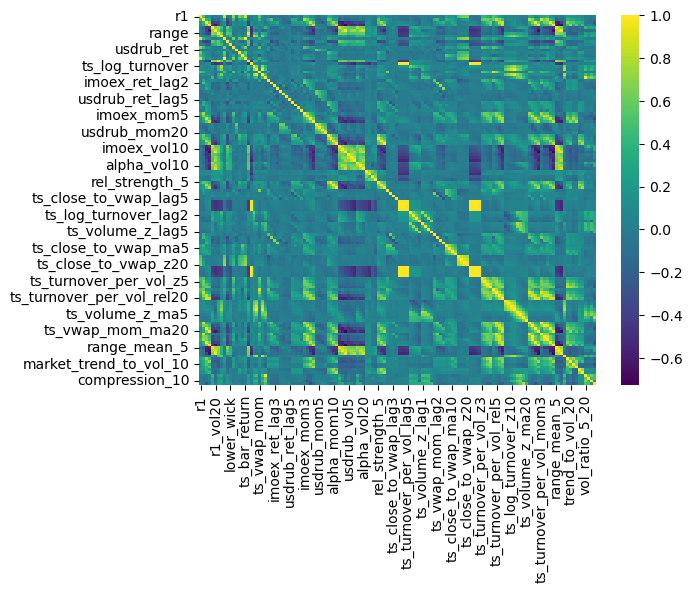

In [35]:
corr_matrix = data[features].corr()
sns.heatmap(corr_matrix, cmap='viridis')

In [36]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) >= 0.995:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j], 
                'correlation': corr_value,
                'abs_correlation': abs(corr_value)
            })
high_corr_pairs

[{'feature1': 'r10',
  'feature2': 'ret_10d',
  'correlation': np.float64(1.0000000000000002),
  'abs_correlation': np.float64(1.0000000000000002)},
 {'feature1': 'r20',
  'feature2': 'ret_20d',
  'correlation': np.float64(0.9999999999999999),
  'abs_correlation': np.float64(0.9999999999999999)},
 {'feature1': 'range',
  'feature2': 'ts_range_norm',
  'correlation': np.float64(1.0),
  'abs_correlation': np.float64(1.0)},
 {'feature1': 'body',
  'feature2': 'ts_bar_return',
  'correlation': np.float64(0.9999999999999994),
  'abs_correlation': np.float64(0.9999999999999994)},
 {'feature1': 'ts_turnover_per_vol',
  'feature2': 'ts_turnover_per_vol_lag1',
  'correlation': np.float64(0.9974263733227041),
  'abs_correlation': np.float64(0.9974263733227041)},
 {'feature1': 'ts_turnover_per_vol',
  'feature2': 'ts_turnover_per_vol_lag2',
  'correlation': np.float64(0.9958448182122982),
  'abs_correlation': np.float64(0.9958448182122982)},
 {'feature1': 'ts_turnover_per_vol',
  'feature2': 'ts_

In [37]:
corr_train = train[features].corr().abs()
upper = corr_train.where(np.triu(np.ones(corr_train.shape), k=1).astype(bool))
auto_drop = [col for col in upper.columns if (upper[col] > 0.995).any()]
features_final = [f for f in features if f not in auto_drop]
len(features_final)

118

In [38]:
X_train = train[features_final]
y_train = train["y"]

X_valid = valid[features_final]
y_valid = valid["y"]

X_test = test[features_final]
y_test = test["y"]

## Backtest

In [39]:
def _to_simple_ret(ret, ret_type='log'):
    ret = np.asarray(ret, dtype=float)

    if ret_type == 'log':
        return np.expm1(ret)
    elif ret_type == 'simple':
        return ret
    else:
        raise ValueError("ret_type must be 'log' or 'simple'")


def _calc_bt_metrics(net_ret, turnover, pos, equity, drawdown, periods_per_year=252):
    net_ret = np.asarray(net_ret, dtype=float)
    turnover = np.asarray(turnover, dtype=float)
    pos = np.asarray(pos)
    equity = np.asarray(equity, dtype=float)
    drawdown = np.asarray(drawdown, dtype=float)

    n = len(net_ret)
    if n == 0:
        return {
            'total_return': 0.0,
            'cagr': 0.0,
            'sharpe': 0.0,
            'sortino': 0.0,
            'vol': 0.0,
            'max_drawdown': 0.0,
            'trades': 0,
            'turnover_mean': 0.0,
            'exposure': 0.0,
            'hit_rate': 0.0,
            'active_hit_rate': 0.0,
            'avg_daily_ret': 0.0,
        }

    mean_ret = net_ret.mean()
    std_ret = net_ret.std(ddof=1) if n > 1 else 0.0

    downside = net_ret[net_ret < 0]
    downside_std = downside.std(ddof=1) if len(downside) > 1 else 0.0

    sharpe = (mean_ret / std_ret) * np.sqrt(periods_per_year) if std_ret > 0 else 0.0
    sortino = (mean_ret / downside_std) * np.sqrt(periods_per_year) if downside_std > 0 else 0.0
    vol = std_ret * np.sqrt(periods_per_year) if std_ret > 0 else 0.0

    total_return = equity[-1] - 1.0
    cagr = equity[-1] ** (periods_per_year / n) - 1.0 if equity[-1] > 0 else -1.0

    active_mask = pos != 0
    active_ret = net_ret[active_mask]

    hit_rate = (net_ret > 0).mean()
    active_hit_rate = (active_ret > 0).mean() if len(active_ret) > 0 else 0.0

    return {
        'total_return': float(total_return),
        'cagr': float(cagr),
        'sharpe': float(sharpe),
        'sortino': float(sortino),
        'vol': float(vol),
        'max_drawdown': float(drawdown.min()),
        'trades': int((turnover > 0).sum()),
        'turnover_mean': float(turnover.mean()),
        'exposure': float((active_mask).mean()),
        'hit_rate': float(hit_rate),
        'active_hit_rate': float(active_hit_rate),
        'avg_daily_ret': float(mean_ret),
    }

In [40]:
def _normalize_signal_ranges(x, name):
    if x is None:
        return {"mode": "ranges", "ranges": []}

    if np.isscalar(x):
        return {"mode": "scalar", "value": float(x)}

    arr = np.asarray(x, dtype=float)

    if arr.ndim == 1:
        if len(arr) == 0:
            return {"mode": "ranges", "ranges": []}
        if len(arr) != 2:
            raise ValueError(f"{name} must be a scalar or list of [lo, hi] pairs")
        arr = arr.reshape(1, 2)

    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError(f"{name} must be a scalar or list of [lo, hi] pairs")

    ranges = []
    for lo, hi in arr:
        lo = float(lo)
        hi = float(hi)

        if not np.isfinite(lo) or not np.isfinite(hi):
            raise ValueError(f"{name} contains non-finite values")

        if lo >= hi:
            raise ValueError(f"Each range in {name} must satisfy lo < hi")

        ranges.append((lo, hi))

    ranges = sorted(ranges, key=lambda z: z[0])

    for i in range(1, len(ranges)):
        prev_lo, prev_hi = ranges[i - 1]
        cur_lo, cur_hi = ranges[i]
        if cur_lo < prev_hi:
            raise ValueError(f"Ranges inside {name} overlap: {(prev_lo, prev_hi)} and {(cur_lo, cur_hi)}")

    return {"mode": "ranges", "ranges": ranges}


def _mask_from_rule(values, rule, side_name):
    values = np.asarray(values, dtype=float)
    mask = np.zeros(len(values), dtype=bool)
    labels = np.full(len(values), "", dtype=object)

    if rule["mode"] == "scalar":
        thr = rule["value"]

        if side_name == "upper":
            mask = values > thr
            labels[mask] = f"upper>{thr:.6f}"
        elif side_name == "lower":
            mask = values < thr
            labels[mask] = f"lower<{thr:.6f}"
        else:
            raise ValueError("side_name must be 'upper' or 'lower'")

        return mask, labels

    for i, (lo, hi) in enumerate(rule["ranges"], 1):
        cur = (values > lo) & (values <= hi)
        mask |= cur
        labels[cur] = f"{side_name}_{i}:({lo:.6f},{hi:.6f}]"

    return mask, labels


def backtest_probs(proba_long,
                   fwd_ret,
                   date=None,
                   lower=0.45,
                   upper=0.55,
                   cost_bps=10,
                   ret_type='log',
                   periods_per_year=252):
    proba_long = np.asarray(proba_long, dtype=float)
    fwd_ret = np.asarray(fwd_ret, dtype=float)

    if len(proba_long) != len(fwd_ret):
        raise ValueError('len(proba_long) must be equal to len(fwd_ret)')

    if date is None:
        date = np.arange(len(proba_long))
    else:
        date = pd.to_datetime(date)

    lower_rule = _normalize_signal_ranges(lower, "lower")
    upper_rule = _normalize_signal_ranges(upper, "upper")

    if lower_rule["mode"] == "scalar" and upper_rule["mode"] == "scalar":
        if lower_rule["value"] >= upper_rule["value"]:
            raise ValueError("For scalar thresholds, lower must be < upper")

    long_mask, long_labels = _mask_from_rule(proba_long, upper_rule, "upper")
    short_mask, short_labels = _mask_from_rule(proba_long, lower_rule, "lower")

    overlap = long_mask & short_mask
    if overlap.any():
        overlap_probs = np.unique(np.round(proba_long[overlap], 8))
        raise ValueError(f"Long/short zones overlap for some probabilities: {overlap_probs[:10]}")

    fwd_ret_simple = _to_simple_ret(fwd_ret, ret_type=ret_type)

    pos = np.zeros(len(proba_long), dtype=np.int8)
    pos[long_mask] = 1
    pos[short_mask] = -1

    signal_zone = np.full(len(proba_long), "flat", dtype=object)
    signal_zone[long_mask] = long_labels[long_mask]
    signal_zone[short_mask] = short_labels[short_mask]

    pos_prev = np.r_[0, pos[:-1]]
    turnover = np.abs(pos - pos_prev).astype(float)

    cost_rate = cost_bps / 10000.0
    cost = turnover * cost_rate

    gross_ret = pos * fwd_ret_simple
    net_ret = gross_ret - cost

    equity = np.cumprod(1.0 + net_ret)
    peak = np.maximum.accumulate(equity)
    drawdown = equity / peak - 1.0

    bt = pd.DataFrame({
        'date': date,
        'proba_long': proba_long,
        'fwd_ret': fwd_ret,
        'fwd_ret_simple': fwd_ret_simple,
        'signal_zone': signal_zone,
        'pos': pos,
        'pos_prev': pos_prev,
        'turnover': turnover,
        'cost': cost,
        'gross_ret': gross_ret,
        'net_ret': net_ret,
        'equity': equity,
        'peak': peak,
        'drawdown': drawdown,
    })

    metrics = _calc_bt_metrics(
        net_ret=bt['net_ret'].values,
        turnover=bt['turnover'].values,
        pos=bt['pos'].values,
        equity=bt['equity'].values,
        drawdown=bt['drawdown'].values,
        periods_per_year=periods_per_year
    )

    yearly = None
    if 'date' in bt.columns and np.issubdtype(bt['date'].dtype, np.datetime64):
        yearly_rows = []

        for year, g in bt.groupby(bt['date'].dt.year):
            eq = (1.0 + g['net_ret']).cumprod().values
            peak_y = np.maximum.accumulate(eq)
            dd_y = eq / peak_y - 1.0

            m = _calc_bt_metrics(
                net_ret=g['net_ret'].values,
                turnover=g['turnover'].values,
                pos=g['pos'].values,
                equity=eq,
                drawdown=dd_y,
                periods_per_year=periods_per_year
            )
            m['year'] = int(year)
            yearly_rows.append(m)

        yearly = pd.DataFrame(yearly_rows)
        if len(yearly) > 0:
            yearly = yearly[['year', 'total_return', 'cagr', 'sharpe', 'sortino',
                             'vol', 'max_drawdown', 'trades', 'turnover_mean',
                             'exposure', 'hit_rate', 'active_hit_rate', 'avg_daily_ret']]

    return {
        'metrics': metrics,
        'bt': bt,
        'yearly': yearly
    }

In [41]:
def optimize_thresholds(proba,
                        fwd_ret,
                        date=None,
                        cost_bps=10,
                        ret_type='log',
                        min_trades=30,
                        min_gap=0.05,
                        score_col='sharpe',
                        lower_grid=None,
                        upper_grid=None):
    if lower_grid is None:
        lower_grid = np.linspace(0.05, 0.49, 45)

    if upper_grid is None:
        upper_grid = np.linspace(0.51, 0.95, 45)

    best = None

    for lo in lower_grid:
        for up in upper_grid:
            if up <= lo + min_gap:
                continue

            res = backtest_probs(
                proba_long=proba,
                fwd_ret=fwd_ret,
                date=date,
                lower=lo,
                upper=up,
                cost_bps=cost_bps,
                ret_type=ret_type
            )

            metrics = res['metrics']

            if metrics['trades'] < min_trades:
                continue

            score = metrics[score_col]

            if (best is None) or (score > best['score']):
                best = {
                    'lower': float(lo),
                    'upper': float(up),
                    'score': float(score),
                    'score_col': score_col,
                    'metrics': metrics,
                    'bt': res['bt'],
                    'yearly': res['yearly']
                }

    return best

In [42]:
def print_bt_report(bt_res):
    m = bt_res['metrics']

    print(f"total_return:    {m['total_return']:.4f}")
    print(f"cagr:            {m['cagr']:.4f}")
    print(f"sharpe:          {m['sharpe']:.4f}")
    print(f"sortino:         {m['sortino']:.4f}")
    print(f"vol:             {m['vol']:.4f}")
    print(f"max_drawdown:    {m['max_drawdown']:.4f}")
    print(f"trades:          {m['trades']}")
    print(f"turnover_mean:   {m['turnover_mean']:.4f}")
    print(f"exposure:        {m['exposure']:.4f}")
    print(f"hit_rate:        {m['hit_rate']:.4f}")
    print(f"active_hit_rate: {m['active_hit_rate']:.4f}")


def plot_bt(bt_res, figsize=(14, 5)):
    bt = bt_res['bt']

    plt.figure(figsize=figsize)
    plt.plot(bt['date'], bt['equity'], label='equity')
    plt.title('Backtest equity')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=figsize)
    plt.plot(bt['date'], bt['drawdown'], label='drawdown')
    plt.title('Backtest drawdown')
    plt.grid()
    plt.legend()
    plt.show()

## ML Models

### Functions

In [43]:
tscv = TimeSeriesSplit(n_splits=5, gap=21)

In [44]:
def eval(model, X, y, thr=0.5):
  probs = model.predict_proba(X)[:,1]
  preds = (probs >= thr).astype(int)
  acc = accuracy_score(y, preds)
  auc = roc_auc_score(y, probs)
  return auc, acc, probs

In [45]:
def best_threshold(y_true, probs):
  thrs = np.linspace(0.1, 0.9, 100)
  best_thr, best_acc = 0.5, -1
  for thr in thrs:
    preds = (probs >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    if acc > best_acc:
      best_acc = acc
      best_thr = thr
  return best_thr, best_acc

In [46]:
def confidence_report(df, probs, label="valid", n_bins=10):
    out = df[["date", "close", "fwd_ret", "y"]].copy().reset_index(drop=True)
    out["proba"] = np.asarray(probs, dtype=float)
    out["score"] = 2.0 * out["proba"] - 1.0
    out["confidence"] = np.abs(out["score"])
    out["pred"] = (out["proba"] >= 0.5).astype(int)
    out["pred_side"] = np.where(out["pred"] == 1, 1.0, -1.0)
    out["next_ret_simple"] = np.expm1(out["fwd_ret"])
    out["next_price_diff"] = out["close"] * out["next_ret_simple"]
    out["aligned_ret"] = out["pred_side"] * out["next_ret_simple"]
    out["correct"] = (out["pred"] == out["y"]).astype(int)

    out = out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    q1 = min(n_bins, out["proba"].nunique())
    q2 = min(n_bins, out["confidence"].nunique())

    out["proba_bin"] = pd.qcut(out["proba"], q=q1, duplicates="drop")
    out["confidence_bin"] = pd.qcut(out["confidence"], q=q2, duplicates="drop")

    proba_table = (
        out.groupby("proba_bin", observed=False)
        .agg(
            n=("proba", "size"),
            mean_proba=("proba", "mean"),
            mean_score=("score", "mean"),
            pos_rate=("y", "mean"),
            accuracy=("correct", "mean"),
            mean_next_ret=("next_ret_simple", "mean"),
            median_next_ret=("next_ret_simple", "median"),
            mean_next_price_diff=("next_price_diff", "mean"),
            mean_aligned_ret=("aligned_ret", "mean"),
            std_aligned_ret=("aligned_ret", "std")
        )
        .reset_index()
    )

    proba_table["mean_next_ret_bp"] = proba_table["mean_next_ret"] * 10000
    proba_table["median_next_ret_bp"] = proba_table["median_next_ret"] * 10000
    proba_table["mean_aligned_ret_bp"] = proba_table["mean_aligned_ret"] * 10000

    confidence_table = (
        out.groupby("confidence_bin", observed=False)
        .agg(
            n=("confidence", "size"),
            mean_confidence=("confidence", "mean"),
            accuracy=("correct", "mean"),
            mean_abs_next_ret=("next_ret_simple", lambda x: np.mean(np.abs(x))),
            mean_next_ret=("next_ret_simple", "mean"),
            mean_aligned_ret=("aligned_ret", "mean"),
            median_aligned_ret=("aligned_ret", "median"),
            mean_next_price_diff=("next_price_diff", "mean")
        )
        .reset_index()
    )

    confidence_table["mean_abs_next_ret_bp"] = confidence_table["mean_abs_next_ret"] * 10000
    confidence_table["mean_next_ret_bp"] = confidence_table["mean_next_ret"] * 10000
    confidence_table["mean_aligned_ret_bp"] = confidence_table["mean_aligned_ret"] * 10000
    confidence_table["median_aligned_ret_bp"] = confidence_table["median_aligned_ret"] * 10000

    stats = pd.Series({
        "label": label,
        "pearson_proba_vs_next_ret": out["proba"].corr(out["next_ret_simple"], method="pearson"),
        "spearman_proba_vs_next_ret": out["proba"].corr(out["next_ret_simple"], method="spearman"),
        "pearson_score_vs_next_ret": out["score"].corr(out["next_ret_simple"], method="pearson"),
        "spearman_score_vs_next_ret": out["score"].corr(out["next_ret_simple"], method="spearman"),
        "pearson_conf_vs_abs_ret": out["confidence"].corr(out["next_ret_simple"].abs(), method="pearson"),
        "spearman_conf_vs_abs_ret": out["confidence"].corr(out["next_ret_simple"].abs(), method="spearman"),
        "pearson_conf_vs_aligned_ret": out["confidence"].corr(out["aligned_ret"], method="pearson"),
        "spearman_conf_vs_aligned_ret": out["confidence"].corr(out["aligned_ret"], method="spearman"),
        "overall_accuracy": out["correct"].mean(),
        "overall_mean_next_ret_bp": out["next_ret_simple"].mean() * 10000,
        "overall_mean_aligned_ret_bp": out["aligned_ret"].mean() * 10000
    })

    return {
        "raw": out,
        "proba_table": proba_table,
        "confidence_table": confidence_table,
        "stats": stats
    }

### XGBoost

**XGBoost Results**

*Cross-Validation Score:* 0.5263

*Best Hyperparameters*

- n_estimators: 208
- learning_rate: 0.144582363692999
- max_depth: 6
- min_child_weight: 23
- subsample: 0.942529716751237
- colsample_bytree: 0.6209261454502258
- gamma: 0.046551383902949606
- reg_alpha: 0.5577427051843638
- reg_lambda: 11.505367449591569
- scale_pos_weight: 1.3079966853429834

In [ ]:
xgb = Pipeline([
    ('xgb', XGBClassifier(
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        n_estimators=208,
        learning_rate=0.01,
        max_depth=10,
        min_child_weight=23
    ))
])
# xgb = xgb_random.best_estimator_

xgb.fit(X_train, y_train)

train_auc, train_acc, _train_probs = eval(xgb, X_train, y_train)
test_auc, test_acc, test_probs = eval(xgb, X_test, y_test)
best_thr, best_acc = best_threshold(y_test, test_probs)

print(f'train roc_auc: {train_auc:.4f} | train accuracy: {train_acc:.4f}')
print(f'test roc_auc: {test_auc:.4f} | test accuracy: {test_acc:.4f}')
print(f'Calibration')
print(f'threshold: {best_thr:.4f} | accuracy: {best_acc:.4f}')

train roc_auc: 0.9397 | train accuracy: 0.8681
test roc_auc: 0.5490 | test accuracy: 0.4825
Calibration
threshold: 0.5364 | accuracy: 0.5614


total_return:    0.0049
cagr:            0.0108
sharpe:          0.1897
sortino:         0.1894
vol:             0.0688
max_drawdown:    -0.0232
trades:          34
turnover_mean:   0.2982
exposure:        0.2281
hit_rate:        0.1316
active_hit_rate: 0.5769


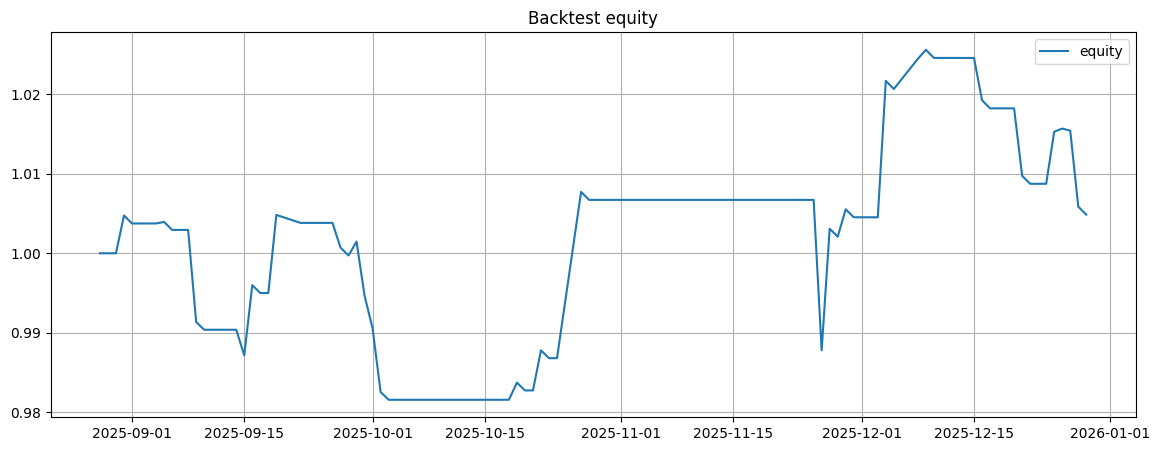

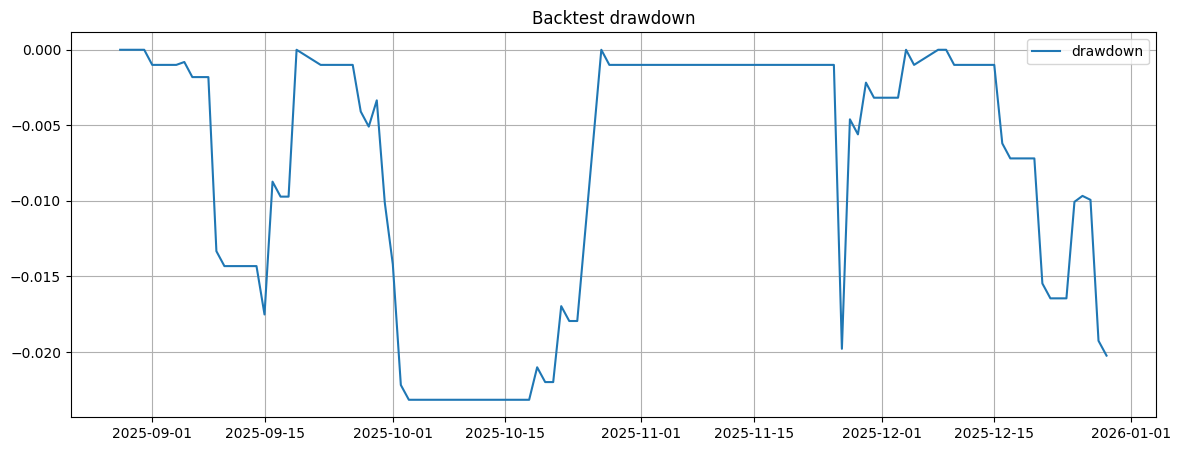

In [ ]:
xgb_bt = backtest_probs(
    proba_long=test_probs,
    fwd_ret=test['fwd_ret'].values,
    date=test['date'].values,
    lower=0.44,
    upper=0.6,
    cost_bps=10,
    ret_type='log'
)

print_bt_report(xgb_bt)
# xgb_bt['yearly']
plot_bt(xgb_bt)

In [ ]:
xgb_best = optimize_thresholds(
    proba=test_probs,
    fwd_ret=test['fwd_ret'].values,
    date=test['date'].values,
    cost_bps=10,
    ret_type='log',
    min_trades=10,
    score_col='sharpe'
)

xgb_best['lower'], xgb_best['upper'], xgb_best['score']
# print_bt_report(xgb_best)
# xgb_best['yearly']
# plot_bt(xgb_best)

(0.44, 0.6, 0.18973703179713575)

### XGBoost Search

In [ ]:
params_grid = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(2, 8),
    'learning_rate': uniform(0.01, 0.15),
    'min_child_weight': randint(1, 25),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0.0, 0.5),
    'reg_alpha': uniform(0.0, 2.0),
    'reg_lambda': uniform(1.0, 15.0),
    'scale_pos_weight': uniform(0.8, 0.6)
}

In [ ]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1
)

In [ ]:
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=params_grid,
    n_iter=60,
    scoring="acc",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

In [ ]:
xgb_random.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=Non...
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b011c16ec30>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b011c16e5d0>,
                                        'scale_pos_weight': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b011c206840>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b011c16e060>},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("Best score:", xgb_random.best_score_)
print("Best params:", xgb_random.best_params_)

Best score: 0.5262606120217759
Best params: {'colsample_bytree': np.float64(0.6209261454502258), 'gamma': np.float64(0.046551383902949606), 'learning_rate': np.float64(0.144582363692999), 'max_depth': 6, 'min_child_weight': 23, 'n_estimators': 208, 'reg_alpha': np.float64(0.5577427051843638), 'reg_lambda': np.float64(11.505367449591569), 'scale_pos_weight': np.float64(1.3079966853429834), 'subsample': np.float64(0.942529716751237)}


### CatBoost

**CatBoost Results**

*Cross-Validation Score:* 0.5263

*Best Hyperparameters*

- border_count: 236
- depth: 3
- iterations: 458
- l2_leaf_reg: 1.1042819579678604
- learning_rate: 0.10704198748973749
- random_strength: 2.087055015743895
- subsample: 0.6888431241882921

In [47]:
best_cat_params = {'bagging_temperature': np.float64(1.554911608578311), 
                   'border_count': 100, 
                   'depth': 4, 
                   'l2_leaf_reg': np.float64(7.4716845866950345), 
                   'learning_rate': np.float64(0.01979131298383819), 
                   'random_strength': np.float64(2.806217129238506)}

In [48]:
cat = CatBoostClassifier(
    iterations=5000,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced",
    bootstrap_type="Bayesian",
    has_time=True,
    **best_cat_params
)

cat.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=200
)

train_auc, train_acc, train_probs_cat = eval(cat, X_train, y_train)
valid_auc, valid_acc, valid_probs_cat = eval(cat, X_valid, y_valid)
test_auc, test_acc, test_probs_cat = eval(cat, X_test, y_test)

print(f"train roc_auc: {train_auc:.4f} | train accuracy: {train_acc:.4f}")
print(f"valid roc_auc: {valid_auc:.4f} | valid accuracy: {valid_acc:.4f}")
print(f"test  roc_auc: {test_auc:.4f} | test  accuracy: {test_acc:.4f}")
print("best_iteration:", cat.get_best_iteration())

0:	learn: 0.5642053	test: 0.4805512	best: 0.4805512 (0)	total: 214ms	remaining: 17m 47s
200:	learn: 0.8415260	test: 0.5436245	best: 0.5516674 (25)	total: 1.77s	remaining: 42.2s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5516673722
bestIteration = 25

Shrink model to first 26 iterations.
train roc_auc: 0.7792 | train accuracy: 0.7027
valid roc_auc: 0.5450 | valid accuracy: 0.5516
test  roc_auc: 0.6745 | test  accuracy: 0.5952
best_iteration: 25


In [98]:
eps = 1e-12

train_fwd_simple = np.expm1(train["fwd_ret"].values)
valid_fwd_simple = np.expm1(valid["fwd_ret"].values)
test_fwd_simple = np.expm1(test["fwd_ret"].values)

train_abs_move = np.abs(train_fwd_simple)
valid_abs_move = np.abs(valid_fwd_simple)
test_abs_move = np.abs(test_fwd_simple)

clip_lo = np.quantile(train_abs_move, 0.01)
clip_hi = np.quantile(train_abs_move, 0.99)

y_train_mag = 
y_valid_mag = 
y_test_mag = 



clip_lo, clip_hi

(np.float64(9.480857112090234e-05), np.float64(0.07387157213421902))

In [99]:
def eval_mag_model(y_true_abs, y_pred_abs, label="split"):
    y_true_abs = np.asarray(y_true_abs, dtype=float)
    y_pred_abs = np.asarray(y_pred_abs, dtype=float)

    rmse = np.sqrt(np.mean((y_true_abs - y_pred_abs) ** 2))
    mae = np.mean(np.abs(y_true_abs - y_pred_abs))
    pearson = pd.Series(y_true_abs).corr(pd.Series(y_pred_abs), method="pearson")
    spearman = pd.Series(y_true_abs).corr(pd.Series(y_pred_abs), method="spearman")

    return pd.Series({
        "label": label,
        "rmse": rmse,
        "mae": mae,
        "pearson_pred_vs_abs_move": pearson,
        "spearman_pred_vs_abs_move": spearman,
        "mean_pred_bp": np.mean(y_pred_abs) * 10000,
        "mean_real_bp": np.mean(y_true_abs) * 10000
    })

In [100]:
reg_param_dist = {
    "depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.015, 0.03, 0.05, 0.07],
    "l2_leaf_reg": [5, 10, 20, 30, 50],
    "random_strength": [0.0, 0.5, 1.0, 2.0, 4.0],
    "bagging_temperature": [0.0, 0.5, 1.0, 2.0, 3.0]
}

reg_param_list = list(ParameterSampler(
    reg_param_dist,
    n_iter=20,
    random_state=42
))

len(reg_param_list)

20

In [101]:
def search_catboost_regressor_mag(
    X_train,
    y_train_mag,
    train_abs_move,
    X_valid,
    y_valid_mag,
    valid_abs_move,
    param_list,
    iterations=5000,
    early_stopping_rounds=200,
    random_seed=42
):
    rows = []

    for i, params in enumerate(param_list, 1):
        print(f"[{i}/{len(param_list)}] {params}")

        model = CatBoostRegressor(
            iterations=iterations,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=random_seed,
            verbose=False,
            bootstrap_type="Bayesian",
            has_time=True,
            **params
        )

        model.fit(
            X_train,
            y_train_mag,
            eval_set=(X_valid, y_valid_mag),
            use_best_model=True,
            early_stopping_rounds=early_stopping_rounds
        )

        train_pred = np.maximum(model.predict(X_train), 0.0) ** 2
        valid_pred = np.maximum(model.predict(X_valid), 0.0) ** 2

        train_eval = eval_mag_model(train_abs_move, train_pred, label="train")
        valid_eval = eval_mag_model(valid_abs_move, valid_pred, label="valid")

        rows.append({
            "params": params,
            "best_iteration": model.get_best_iteration(),
            "train_rmse": train_eval["rmse"],
            "valid_rmse": valid_eval["rmse"],
            "train_mae": train_eval["mae"],
            "valid_mae": valid_eval["mae"],
            "train_pearson": train_eval["pearson_pred_vs_abs_move"],
            "valid_pearson": valid_eval["pearson_pred_vs_abs_move"],
            "train_spearman": train_eval["spearman_pred_vs_abs_move"],
            "valid_spearman": valid_eval["spearman_pred_vs_abs_move"],
            "spearman_gap": train_eval["spearman_pred_vs_abs_move"] - valid_eval["spearman_pred_vs_abs_move"]
        })

    results = pd.DataFrame(rows).sort_values(
        ["valid_spearman", "valid_rmse", "spearman_gap"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    return results

In [102]:
reg_search_results = search_catboost_regressor_mag(
    X_train=X_train,
    y_train_mag=y_train_mag,
    train_abs_move=train_abs_move,
    X_valid=X_valid,
    y_valid_mag=y_valid_mag,
    valid_abs_move=valid_abs_move,
    param_list=reg_param_list,
    iterations=5000,
    early_stopping_rounds=200,
    random_seed=42
)

reg_search_results.head(10)

[1/20] {'random_strength': 0.0, 'learning_rate': 0.015, 'l2_leaf_reg': 30, 'depth': 5, 'bagging_temperature': 0.5}
[2/20] {'random_strength': 4.0, 'learning_rate': 0.05, 'l2_leaf_reg': 50, 'depth': 4, 'bagging_temperature': 1.0}
[3/20] {'random_strength': 0.0, 'learning_rate': 0.05, 'l2_leaf_reg': 10, 'depth': 3, 'bagging_temperature': 1.0}
[4/20] {'random_strength': 0.0, 'learning_rate': 0.07, 'l2_leaf_reg': 50, 'depth': 2, 'bagging_temperature': 1.0}
[5/20] {'random_strength': 2.0, 'learning_rate': 0.07, 'l2_leaf_reg': 10, 'depth': 3, 'bagging_temperature': 2.0}
[6/20] {'random_strength': 4.0, 'learning_rate': 0.03, 'l2_leaf_reg': 30, 'depth': 3, 'bagging_temperature': 3.0}
[7/20] {'random_strength': 0.5, 'learning_rate': 0.03, 'l2_leaf_reg': 30, 'depth': 6, 'bagging_temperature': 0.0}
[8/20] {'random_strength': 2.0, 'learning_rate': 0.07, 'l2_leaf_reg': 10, 'depth': 4, 'bagging_temperature': 1.0}
[9/20] {'random_strength': 0.0, 'learning_rate': 0.05, 'l2_leaf_reg': 10, 'depth': 5, '

,params,best_iteration,train_rmse,valid_rmse,train_mae,valid_mae,train_pearson,valid_pearson,train_spearman,valid_spearman,spearman_gap
0,"{'random_strength': 0.0, 'learning_rate': 0.01...",1238,0.019424,0.017219,0.012577,0.011481,0.762437,0.226237,0.640805,0.341422,0.299383
1,"{'random_strength': 0.0, 'learning_rate': 0.07...",230,0.019377,0.017216,0.012567,0.011477,0.796439,0.238753,0.698601,0.340791,0.357810
2,"{'random_strength': 4.0, 'learning_rate': 0.03...",540,0.019537,0.017209,0.012596,0.011470,0.678673,0.253924,0.489534,0.338611,0.150923
3,"{'random_strength': 0.5, 'learning_rate': 0.03...",479,0.019448,0.017223,0.012588,0.011485,0.747532,0.224363,0.620021,0.335959,0.284062
4,"{'random_strength': 1.0, 'learning_rate': 0.01...",1142,0.019550,0.017218,0.012607,0.011476,0.717480,0.228085,0.579711,0.335677,0.244034
5,"{'random_strength': 0.0, 'learning_rate': 0.07...",213,0.019564,0.017214,0.012601,0.011470,0.635989,0.180419,0.453206,0.325849,0.127357
6,"{'random_strength': 0.0, 'learning_rate': 0.03...",333,0.019622,0.017215,0.012620,0.011471,0.638972,0.199365,0.450632,0.323841,0.126790
7,"{'random_strength': 4.0, 'learning_rate': 0.05...",505,0.019521,0.017206,0.012593,0.011465,0.702148,0.240160,0.527984,0.320939,0.207044
8,"{'random_strength': 0.0, 'learning_rate': 0.05...",258,0.019329,0.017213,0.012556,0.011478,0.792107,0.190821,0.666606,0.317630,0.348976
9,"{'random_strength': 2.0, 'learning_rate': 0.07...",174,0.019496,0.017205,0.012587,0.011466,0.698792,0.236438,0.503828,0.316522,0.187306


In [104]:
best_reg_params = {'random_strength': 4.0,
 'learning_rate': 0.03,
 'l2_leaf_reg': 30,
 'depth': 4,
 'bagging_temperature': 0.5}

In [105]:
reg_mag = CatBoostRegressor(
    iterations=5000,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200,
    bootstrap_type="Bayesian",
    has_time=True,
    **best_reg_params
)

reg_mag.fit(
    X_train,
    y_train_mag,
    eval_set=(X_valid, y_valid_mag),
    use_best_model=True,
    early_stopping_rounds=200
)

train_pred_mag = np.maximum(reg_mag.predict(X_train), 0.0) ** 2
valid_pred_mag = np.maximum(reg_mag.predict(X_valid), 0.0) ** 2
test_pred_mag = np.maximum(reg_mag.predict(X_test), 0.0) ** 2

print("best_iteration:", reg_mag.get_best_iteration())

0:	learn: 0.0151333	test: 0.0128827	best: 0.0128827 (0)	total: 15.4ms	remaining: 1m 17s
200:	learn: 0.0125866	test: 0.0124536	best: 0.0124453 (170)	total: 1.09s	remaining: 25.9s
400:	learn: 0.0117168	test: 0.0124202	best: 0.0124200 (396)	total: 2.17s	remaining: 24.9s
600:	learn: 0.0111117	test: 0.0124126	best: 0.0123996 (540)	total: 3.22s	remaining: 23.6s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.01239956626
bestIteration = 540

Shrink model to first 541 iterations.
best_iteration: 540


In [106]:
pd.concat([
    eval_mag_model(train_abs_move, train_pred_mag, "train"),
    eval_mag_model(valid_abs_move, valid_pred_mag, "valid"),
    eval_mag_model(test_abs_move, test_pred_mag, "test")
], axis=1)

,0,1,2
label,train,valid,test
rmse,0.019537,0.017209,0.007006
mae,0.012596,0.01147,0.005454
pearson_pred_vs_abs_move,0.678673,0.253924,0.064605
spearman_pred_vs_abs_move,0.489534,0.338611,0.041774
mean_pred_bp,2.138532,1.36874,0.586623
mean_real_bp,128.088969,116.06302,55.12495


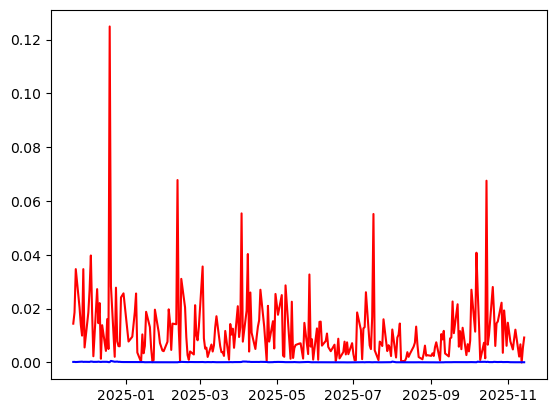

In [109]:
plt.plot(valid['date'], valid_abs_move, 'r-')
plt.plot(valid['date'], valid_pred_mag, 'b-')

In [51]:
best_threshold(y_valid, valid_probs_cat)

(np.float64(0.49595959595959593), 0.5555555555555556)

In [56]:
valid_report = confidence_report(valid, valid_probs_cat, label="valid", n_bins=10)
test_report = confidence_report(test, test_probs_cat, label="test", n_bins=10)

In [57]:
valid_report["proba_table"][
    [
        "proba_bin",
        "n",
        "mean_proba",
        "pos_rate",
        "accuracy",
        "mean_next_ret_bp",
        "median_next_ret_bp",
        "mean_next_price_diff",
        "mean_aligned_ret_bp"
    ]
]

,proba_bin,n,mean_proba,pos_rate,accuracy,mean_next_ret_bp,median_next_ret_bp,mean_next_price_diff,mean_aligned_ret_bp
0,"(0.47, 0.487]",26,0.482138,0.461538,0.538462,19.667738,-27.721775,0.235769,-19.667738
1,"(0.487, 0.493]",25,0.489986,0.400000,0.600000,-37.173513,-23.124790,-0.969200,37.173513
2,"(0.493, 0.495]",25,0.493900,0.480000,0.520000,57.682473,-29.357330,1.473600,-57.682473
3,"(0.495, 0.497]",25,0.496324,0.520000,0.480000,-17.776084,15.531239,-0.498800,17.776084
4,"(0.497, 0.5]",25,0.498680,0.440000,0.560000,22.275740,-7.416962,0.706400,-22.275740
5,"(0.5, 0.503]",25,0.501560,0.680000,0.680000,13.255649,21.966318,0.392800,13.255649
6,"(0.503, 0.506]",25,0.504711,0.560000,0.560000,-2.240827,9.469697,-0.158400,-2.240827
7,"(0.506, 0.509]",25,0.507308,0.480000,0.480000,3.546137,-15.408805,-0.134400,3.546137
8,"(0.509, 0.513]",25,0.510186,0.560000,0.560000,29.066566,5.663583,0.914800,29.066566
9,"(0.513, 0.528]",26,0.516253,0.538462,0.538462,12.283377,10.364492,0.320385,12.283377


In [58]:
test_report["proba_table"][
    [
        "proba_bin",
        "n",
        "mean_proba",
        "pos_rate",
        "accuracy",
        "mean_next_ret_bp",
        "median_next_ret_bp",
        "mean_next_price_diff",
        "mean_aligned_ret_bp"
    ]
]

,proba_bin,n,mean_proba,pos_rate,accuracy,mean_next_ret_bp,median_next_ret_bp,mean_next_price_diff,mean_aligned_ret_bp
0,"(0.487, 0.496]",9,0.492926,0.555556,0.444444,10.643424,10.040833,0.322222,-10.643424
1,"(0.496, 0.498]",8,0.497369,0.250000,0.750000,-21.992034,-26.575852,-0.670000,21.992034
2,"(0.498, 0.503]",8,0.500718,0.250000,0.375000,-53.209642,-58.034494,-1.625000,-29.987269
3,"(0.503, 0.505]",9,0.503519,0.444444,0.444444,7.607044,-7.895152,0.214444,7.607044
4,"(0.505, 0.506]",8,0.505379,0.375000,0.375000,-6.983338,-33.815927,-0.225000,-6.983338
5,"(0.506, 0.509]",8,0.507215,0.625000,0.625000,15.496587,13.821493,0.466250,15.496587
6,"(0.509, 0.511]",9,0.510646,0.777778,0.777778,25.817570,27.463754,0.788889,25.817570
7,"(0.511, 0.514]",8,0.512436,0.625000,0.625000,35.504050,34.386994,1.065000,35.504050
8,"(0.514, 0.516]",8,0.514581,0.750000,0.750000,42.964739,24.131070,1.317500,42.964739
9,"(0.516, 0.526]",9,0.519783,0.777778,0.777778,39.919370,41.258053,1.213333,39.919370


total_return:    0.0854
cagr:            0.2787
sharpe:          2.2694
sortino:         4.4255
vol:             0.1111
max_drawdown:    -0.0346
trades:          1
turnover_mean:   0.0119
exposure:        1.0000
hit_rate:        0.5476
active_hit_rate: 0.5476


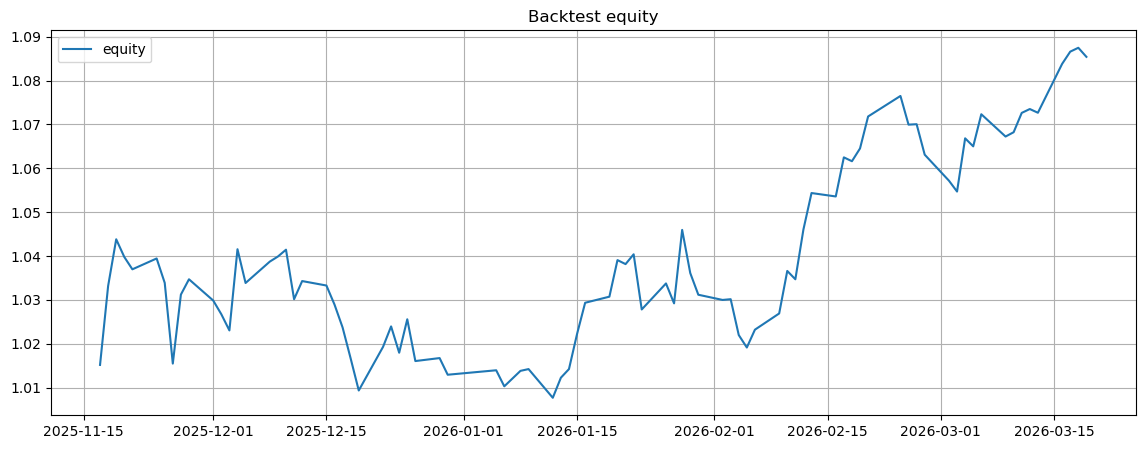

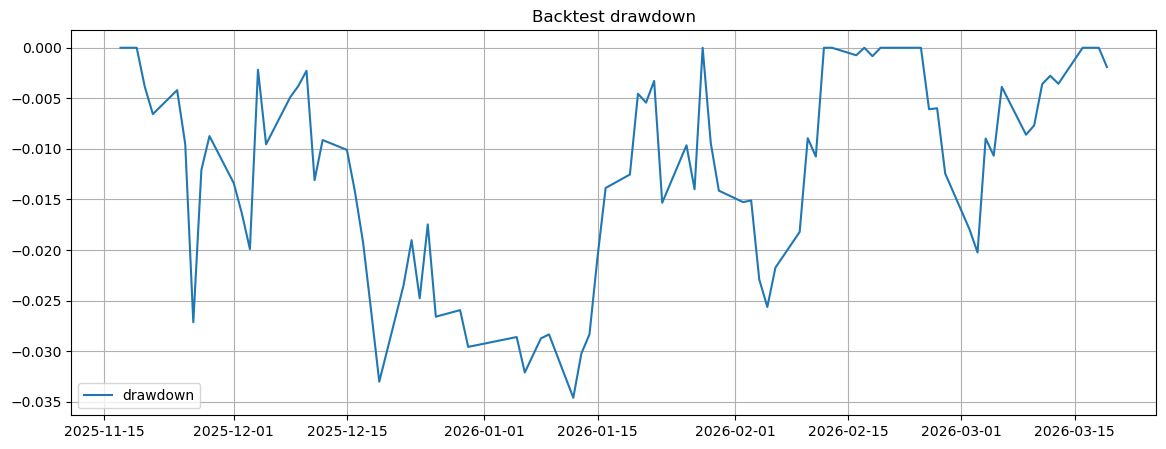

In [50]:
cat_bt = backtest_probs(
    proba_long=test_probs_cat,
    fwd_ret=test['fwd_ret'].values,
    date=test['date'].values,
    lower=0.487878787878787,
    upper=0.487878787878789,
    cost_bps=10,
    ret_type='log'
)

print_bt_report(cat_bt)
# cat_bt['yearly']
plot_bt(cat_bt)

In [60]:
cat_importance = pd.DataFrame({
    'feature': features_final,
    'importance': cat.get_feature_importance()
}).sort_values('importance', ascending=False)
cat_importance.head(10)


,feature,importance
38,usdrub_mom5,6.397746
0,r1,6.066355
13,alpha_1d,3.768327
65,ts_log_turnover_lag3,3.741197
39,usdrub_mom10,3.533864
98,ts_volume_z_ma10,3.505467
100,ts_vwap_mom_ma3,3.491957
80,ts_close_to_vwap_z5,3.385366
81,ts_close_to_vwap_z10,3.229536
10,lower_wick,2.997303


In [61]:
sum(cat_importance['importance'].head(30))

76.83519068538956

In [62]:
features_final = list(cat_importance['feature'].head(30).values)

In [63]:
valid_report["stats"]

label                               valid
pearson_proba_vs_next_ret        0.011425
spearman_proba_vs_next_ret       0.057422
pearson_score_vs_next_ret        0.011425
spearman_score_vs_next_ret       0.057422
pearson_conf_vs_abs_ret          0.059875
spearman_conf_vs_abs_ret          0.12622
pearson_conf_vs_aligned_ret      0.011731
spearman_conf_vs_aligned_ret     0.019941
overall_accuracy                 0.551587
overall_mean_next_ret_bp        10.105685
overall_mean_aligned_ret_bp      1.085236
dtype: object

In [64]:
valid_report["confidence_table"][
    [
        "confidence_bin",
        "n",
        "mean_confidence",
        "accuracy",
        "mean_abs_next_ret_bp",
        "mean_next_ret_bp",
        "mean_aligned_ret_bp",
        "median_aligned_ret_bp",
        "mean_next_price_diff"
    ]
]

,confidence_bin,n,mean_confidence,accuracy,mean_abs_next_ret_bp,mean_next_ret_bp,mean_aligned_ret_bp,median_aligned_ret_bp,mean_next_price_diff
0,"(-0.000936, 0.00305]",26,0.001489,0.653846,59.198383,6.737832,-0.433005,16.508911,0.246538
1,"(0.00305, 0.00534]",25,0.004403,0.520000,127.862267,38.957599,-23.563792,7.416962,1.156000
2,"(0.00534, 0.00805]",25,0.006985,0.560000,111.077639,28.348197,-4.241640,9.469697,0.797600
3,"(0.00805, 0.0112]",25,0.009797,0.600000,122.275943,-49.278674,51.550105,29.957295,-1.391200
4,"(0.0112, 0.0132]",25,0.012143,0.560000,99.217144,-64.189075,29.102573,27.471572,-1.900000
5,"(0.0132, 0.0171]",25,0.014977,0.400000,187.516403,120.085493,-93.683927,-15.408805,2.992800
6,"(0.0171, 0.0205]",25,0.018531,0.440000,97.926312,-0.121051,22.149763,-18.509498,0.120800
7,"(0.0205, 0.0255]",25,0.022367,0.680000,98.527084,-6.545443,32.127906,46.665506,-0.180000
8,"(0.0255, 0.0323]",25,0.027873,0.520000,136.956481,5.208788,10.804845,15.175977,-0.006800
9,"(0.0323, 0.0581]",26,0.040468,0.576923,122.105434,21.530888,-12.361858,16.704798,0.441923


### CatBoost Search

In [46]:
cat_param_dist = {
    "depth": randint(2, 9),
    "learning_rate": scipy.stats.loguniform(0.01, 0.12),
    "l2_leaf_reg": scipy.stats.loguniform(1.0, 30.0),
    "random_strength": uniform(0.0, 5.0),
    "bagging_temperature": uniform(0.0, 5.0),
    "border_count": randint(64, 256)
}

cat_param_list = list(ParameterSampler(
    param_distributions=cat_param_dist,
    n_iter=40,
    random_state=42
))

len(cat_param_list)

40

In [47]:
def catboost_ts_search(
    X,
    y,
    param_list,
    splitter,
    random_seed=42,
    iterations=5000,
    early_stopping_rounds=200
):
    rows = []

    for i, params in enumerate(param_list, 1):
        fold_aucs = []
        fold_iters = []

        print(f"[{i}/{len(param_list)}] {params}")

        for fold, (tr_idx, va_idx) in enumerate(splitter.split(X), 1):
            X_tr = X.iloc[tr_idx]
            y_tr = y.iloc[tr_idx]
            X_va = X.iloc[va_idx]
            y_va = y.iloc[va_idx]

            model = CatBoostClassifier(
                iterations=iterations,
                loss_function="Logloss",
                eval_metric="AUC",
                random_seed=random_seed,
                verbose=False,
                auto_class_weights="Balanced",
                bootstrap_type="Bayesian",
                has_time=True,
                **params
            )

            model.fit(
                X_tr,
                y_tr,
                eval_set=(X_va, y_va),
                use_best_model=True,
                early_stopping_rounds=early_stopping_rounds
            )

            va_probs = model.predict_proba(X_va)[:, 1]
            va_auc = roc_auc_score(y_va, va_probs)

            fold_aucs.append(va_auc)
            fold_iters.append(model.get_best_iteration())

        rows.append({
            "params": params,
            "mean_auc": float(np.mean(fold_aucs)),
            "std_auc": float(np.std(fold_aucs)),
            "min_auc": float(np.min(fold_aucs)),
            "max_auc": float(np.max(fold_aucs)),
            "mean_best_iteration": int(np.mean(fold_iters))
        })

    results = pd.DataFrame(rows).sort_values(
        ["mean_auc", "std_auc"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return results

In [48]:
cat_search_results = catboost_ts_search(
    X=X_train,
    y=y_train,
    param_list=cat_param_list,
    splitter=tscv,
    random_seed=42,
    iterations=5000,
    early_stopping_rounds=200
)

[1/40] {'bagging_temperature': np.float64(1.8727005942368125), 'border_count': 156, 'depth': 8, 'l2_leaf_reg': np.float64(12.057126287443763), 'learning_rate': np.float64(0.04426505507739147), 'random_strength': np.float64(0.7800932022121826)}
[2/40] {'bagging_temperature': np.float64(0.7799726016810132), 'border_count': 138, 'depth': 4, 'l2_leaf_reg': np.float64(19.030368381735816), 'learning_rate': np.float64(0.04453608604723946), 'random_strength': np.float64(3.540362888980227)}
[3/40] {'bagging_temperature': np.float64(0.10292247147901223), 'border_count': 65, 'depth': 5, 'l2_leaf_reg': np.float64(24.341994231042282), 'learning_rate': np.float64(0.010019370340482822), 'random_strength': np.float64(4.961057796456087)}
[4/40] {'bagging_temperature': np.float64(3.0874075481385828), 'border_count': 121, 'depth': 7, 'l2_leaf_reg': np.float64(1.024325040703381), 'learning_rate': np.float64(0.01058981898377947), 'random_strength': np.float64(2.6238733012919457)}
[5/40] {'bagging_temperatu

In [49]:
cat_search_results.head(10)

,params,mean_auc,std_auc,min_auc,max_auc,mean_best_iteration
0,"{'bagging_temperature': 0.6966572720293784, 'b...",0.559140,0.037750,0.512830,0.626905,91
1,"{'bagging_temperature': 1.554911608578311, 'bo...",0.554042,0.021650,0.527020,0.588943,9
2,"{'bagging_temperature': 0.22613644455269033, '...",0.553130,0.020594,0.527782,0.587361,80
3,"{'bagging_temperature': 3.534286719238086, 'bo...",0.552808,0.016485,0.536208,0.580541,13
4,"{'bagging_temperature': 0.3252579649263976, 'b...",0.550403,0.014209,0.532613,0.569314,140
5,"{'bagging_temperature': 1.2803416138066197, 'b...",0.548490,0.004268,0.542244,0.555639,61
6,"{'bagging_temperature': 1.039708314340944, 'bo...",0.547382,0.013549,0.534065,0.570952,109
7,"{'bagging_temperature': 2.571172192068058, 'bo...",0.545361,0.006505,0.536630,0.552618,22
8,"{'bagging_temperature': 1.7837666334679465, 'b...",0.545224,0.019568,0.516771,0.562542,170
9,"{'bagging_temperature': 2.019180855290204, 'bo...",0.544599,0.016389,0.526240,0.573174,6


In [50]:
best_cat_params = cat_search_results.iloc[0]["params"]
best_cat_mean_iter = int(cat_search_results.iloc[0]["mean_best_iteration"])

print(best_cat_params)
print(best_cat_mean_iter)

{'bagging_temperature': np.float64(0.6966572720293784), 'border_count': 206, 'depth': 4, 'l2_leaf_reg': np.float64(1.9950144748611585), 'learning_rate': np.float64(0.10411418194982335), 'random_strength': np.float64(2.99432733244268)}
91


## DL Models

### DL Proprocessing

In [43]:
# Окна

In [44]:
scaler = StandardScaler()
scaled_train = scaler.fit_transform(train[features_final].values)
scaled_valid = scaler.transform(valid[features_final].values)

In [45]:
window = 30
t = 1
y_train = train["y"].values
y_valid = valid["y"].values

In [46]:
X_train_seq, y_train_seq = [], []
for i in range(window - 1, train_size, t):
    X_train_seq.append(scaled_train[i - window + 1 : i + 1])
    y_train_seq.append(y_train[i])

In [47]:
X_valid_seq, y_valid_seq = [], []
for i in range(window - 1, len(valid), t):
    X_valid_seq.append(scaled_valid[i - window + 1 : i + 1])
    y_valid_seq.append(y_valid[i])

In [48]:
X_train_seq = np.array(X_train_seq, dtype=np.float32)
y_train_seq = np.array(y_train_seq, dtype=np.int8)
X_valid_seq = np.array(X_valid_seq, dtype=np.float32)
y_valid_seq = np.array(y_valid_seq, dtype=np.int8)

In [49]:
y_train_seq.mean(), y_valid_seq.mean()

(np.float64(0.5363214837712519), np.float64(0.5112107623318386))

In [50]:
# DataLoaders

In [51]:
batch_size = 128

In [52]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_seq), torch.tensor(y_train_seq)),
    batch_size=batch_size,
    shuffle=True
)
valid_loader = DataLoader(
    TensorDataset(torch.tensor(X_valid_seq), torch.tensor(y_valid_seq)),
    batch_size=batch_size,
    shuffle=False
)

In [53]:
# функции для обучения и валидации

In [54]:
def bce_pos_weight(y_int: np.ndarray):
    pos = y_int.sum()
    neg = len(y_int) - pos
    if pos == 0:
        return None
    return torch.tensor([neg / pos], dtype=torch.float32)

In [55]:
def train(model, train_loader, optimizer, loss_fn, device, clip_norm=1.0):
    model.train()
    train_loss = 0

    probs_list = []
    y_list = []

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).float().unsqueeze(-1)

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        if clip_norm is not None:
          torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()
        train_loss += loss.item()

        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        probs_list.append(probs)
        y_list.append(y.detach().cpu().numpy().reshape(-1))

    probs_all = np.concatenate(probs_list)
    y_all = np.concatenate(y_list).astype(int)

    preds = (probs_all >= 0.5).astype(int)
    acc = accuracy_score(y_all, preds)
    auc = roc_auc_score(y_all, probs_all)

    train_loss /= len(train_loader)
    return train_loss, acc, auc

In [56]:
@torch.inference_mode()
def evaluate(model, test_loader, loss_fn, device):
    model.eval()
    test_loss = 0

    probs_list = []
    y_list = []

    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device).float().unsqueeze(-1)

        logits = model(x)
        loss = loss_fn(logits, y)
        test_loss += loss.item()

        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        probs_list.append(probs)
        y_list.append(y.detach().cpu().numpy().reshape(-1))

    test_loss /= len(test_loader)
    probs_all = np.concatenate(probs_list)
    y_all = np.concatenate(y_list).astype(int)

    preds = (probs_all >= 0.5).astype(int)
    acc = accuracy_score(y_all, preds)
    auc = roc_auc_score(y_all, probs_all)

    return test_loss, acc, auc

In [57]:
def whole_cycle(model, train_loader, test_loader, optimizer, loss_fn, scheduler, device, num_epochs, patience):
    best_val_auc = -1
    best_weights = None
    bad = 0
    train_loss, test_loss = [], []

    for epoch in range(num_epochs):
        tr_loss, tr_acc, _ = train(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc, val_auc = evaluate(model, test_loader, loss_fn, device)
        scheduler.step(val_loss)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_weights = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1

        print(f"{epoch+1}/{num_epochs}: train: {tr_loss:.4f} | test: {val_loss:.4f} | train_accuracy: {tr_acc:.3f} | test_accuracy: {val_acc:.3f} | roc_auc: {val_auc:.3f}")

        if bad >= patience:
            print(f'Early stop epoch: {epoch+1}')
            break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return loss_fn

In [58]:
@torch.inference_mode()
def get_predictions(model, loader, device):
    model.eval()
    probs_list = []
    y_list = []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

        probs_list.append(probs)
        y_list.append(y.cpu().numpy().reshape(-1))

    probs_all = np.concatenate(probs_list)
    y_all = np.concatenate(y_list).astype(int)

    return probs_all, y_all

### LSTM

In [ ]:
class MarketLSTM(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.rnn(x)        # (B, W, H)
        last = out[:, -1, :]        # (B, H)
        return self.head(last)      # (B, 1)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MarketLSTM(n_features=len(features_final), hidden=8).to(device)
pw = bce_pos_weight(y_train_seq)
loss = nn.BCEWithLogitsLoss(pos_weight=pw.to(device))
optimizer = optim.AdamW(params=model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
loss_lstm = whole_cycle(
    model=model,
    train_loader=train_loader,
    test_loader=valid_loader,
    optimizer=optimizer,
    loss_fn=loss,
    scheduler=scheduler,
    device=device,
    num_epochs=50,
    patience=15
)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


### GRU

In [59]:
class MarketGRU(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MarketGRU(n_features=len(features_final), hidden=16).to(device)
pw = bce_pos_weight(y_train_seq)
loss = nn.BCEWithLogitsLoss(pos_weight=pw.to(device))
optimizer = optim.AdamW(params=model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

In [63]:
loss_gru = whole_cycle(
    model=model,
    train_loader=train_loader,
    test_loader=valid_loader,
    optimizer=optimizer,
    loss_fn=loss,
    scheduler=scheduler,
    device=device,
    num_epochs=100,
    patience=20
)

1/100: train: 0.6650 | test: 0.6675 | train_accuracy: 0.502 | test_accuracy: 0.498 | roc_auc: 0.500
2/100: train: 0.6430 | test: 0.6669 | train_accuracy: 0.515 | test_accuracy: 0.525 | roc_auc: 0.496
3/100: train: 0.6500 | test: 0.6658 | train_accuracy: 0.518 | test_accuracy: 0.529 | roc_auc: 0.497
4/100: train: 0.6387 | test: 0.6643 | train_accuracy: 0.527 | test_accuracy: 0.538 | roc_auc: 0.500
5/100: train: 0.6496 | test: 0.6626 | train_accuracy: 0.532 | test_accuracy: 0.520 | roc_auc: 0.505
6/100: train: 0.6361 | test: 0.6605 | train_accuracy: 0.555 | test_accuracy: 0.525 | roc_auc: 0.510
7/100: train: 0.6308 | test: 0.6588 | train_accuracy: 0.563 | test_accuracy: 0.511 | roc_auc: 0.515
8/100: train: 0.6452 | test: 0.6574 | train_accuracy: 0.564 | test_accuracy: 0.502 | roc_auc: 0.519
9/100: train: 0.6325 | test: 0.6553 | train_accuracy: 0.566 | test_accuracy: 0.511 | roc_auc: 0.522
10/100: train: 0.6311 | test: 0.6533 | train_accuracy: 0.564 | test_accuracy: 0.538 | roc_auc: 0.526

0.4 0.7
total_return:    0.1107
cagr:            0.1259
sharpe:          0.9834
sortino:         0.9021
vol:             0.1290
max_drawdown:    -0.1026
trades:          53
turnover_mean:   0.2377
exposure:        0.2332
hit_rate:        0.1345
active_hit_rate: 0.5769


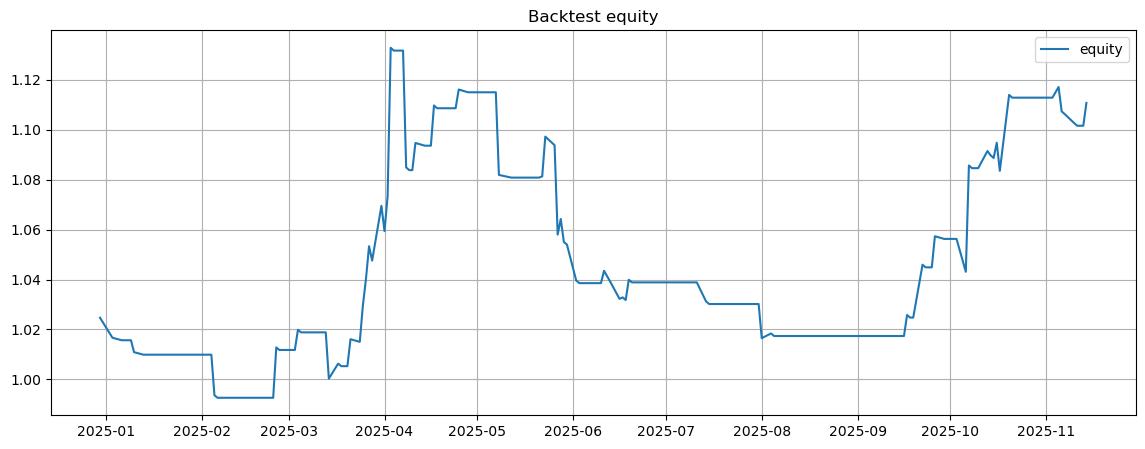

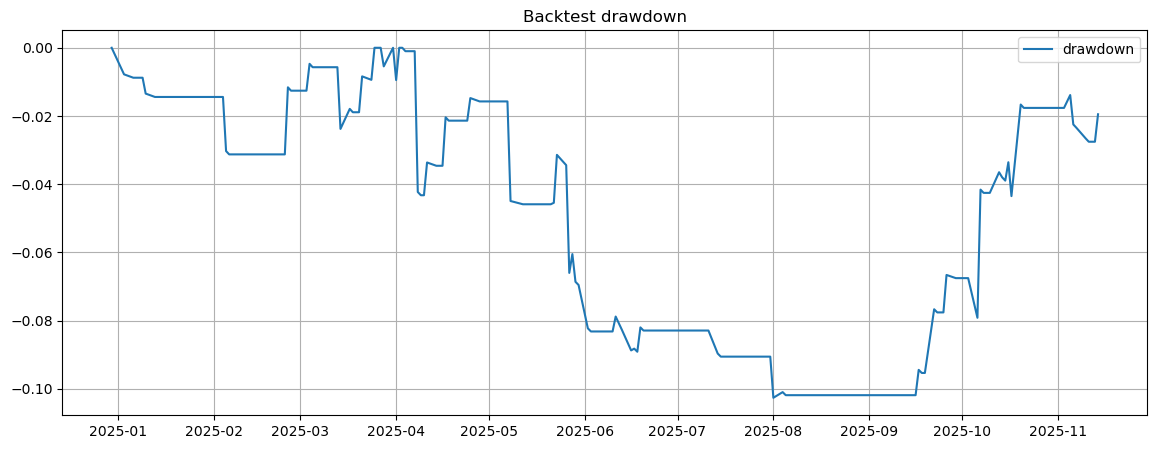

In [67]:
valid_probs_seq, y_valid_seq_pred = get_predictions(model, valid_loader, device)
fwd_ret_seq = valid['fwd_ret'].values[window - 1:]
date_seq = valid['date'].values[window - 1:]

gru_best = optimize_thresholds(
    proba=valid_probs_seq,
    fwd_ret=fwd_ret_seq,
    date=date_seq,
    cost_bps=10,
    ret_type='log',
    min_trades=30,
    score_col='sharpe'
)

print(gru_best['lower'], gru_best['upper'])
print_bt_report(gru_best)
# gru_best['yearly']
plot_bt(gru_best)

In [68]:
valid_probs_seq

array([0.35717598, 0.39020786, 0.5006913 , 0.5507582 , 0.4984864 ,
       0.3868885 , 0.4784382 , 0.49892557, 0.46401203, 0.54188144,
       0.50044763, 0.56679666, 0.6395085 , 0.6699418 , 0.5287462 ,
       0.5342379 , 0.5623938 , 0.5230458 , 0.45102346, 0.50236493,
       0.50656027, 0.5268725 , 0.522281  , 0.3903297 , 0.42947954,
       0.5085781 , 0.5335552 , 0.5225422 , 0.42629433, 0.5912179 ,
       0.53940797, 0.48248303, 0.6164989 , 0.49703258, 0.40356314,
       0.4353503 , 0.43686616, 0.39343372, 0.4066026 , 0.4823186 ,
       0.43022147, 0.40897113, 0.38053104, 0.46896094, 0.5398479 ,
       0.56463057, 0.5787682 , 0.4850699 , 0.40126425, 0.40615097,
       0.31944385, 0.38904065, 0.47660407, 0.5219164 , 0.4116635 ,
       0.3622869 , 0.35933352, 0.27637485, 0.3258737 , 0.34170425,
       0.33739898, 0.30464697, 0.32146788, 0.38372123, 0.33894148,
       0.40569377, 0.44061324, 0.37613684, 0.48073918, 0.44097307,
       0.36808607, 0.47383046, 0.5544319 , 0.5105001 , 0.39966

### TCN